In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
import warnings
import IPython
from IPython.display import display, Markdown
import sys
import gc

version_info = f"""
### Environment Setup
- **Python:** `{sys.version.split()[0]}`
- **Pandas:** `{pd.__version__}`
- **NumPy:** `{np.__version__}`
- **Matplotlib:** `{matplotlib.__version__}`
- **Seaborn:** `{sns.__version__}`
- **NetworkX:** `{nx.__version__}`
- **Mlxtend:** `{mlxtend.__version__}`
- **IPython:** `{IPython.__version__}`
"""
display(Markdown(version_info))

# --- Setup & Optimization ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mlxtend')
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def optimize_types(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

# --- Data Loading & Preprocessing ---
def load_and_prep_data(sample_orders=2e5):
    products = pd.read_csv('products.csv')
    aisles = pd.read_csv('aisles.csv')
    departments = pd.read_csv('departments.csv')
    orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]
    all_order_ids = pd.read_csv('order_products__prior.csv', usecols=['order_id'])['order_id'].unique()
    
    np.random.seed(42)
    sampled_ids = np.random.choice(all_order_ids, size=int(sample_orders), replace=False)
    order_products = pd.read_csv('order_products__prior.csv')
    order_products = order_products[order_products['order_id'].isin(sampled_ids)]
    
    df = order_products.merge(products, on='product_id', how='left')
    df = df.merge(aisles, on='aisle_id', how='left')
    df = df.merge(departments, on='department_id', how='left')
    df = df.merge(orders, on='order_id', how='left')

    # Dimensional Engineering
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = 'Hour_' + pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False).astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    
    return optimize_types(df)

# --- Exploratory Data Analysis ---
def run_eda(df):
    display(Markdown("## Exploratory Data Analysis"))
    
    # 1. Missing Values Check
    display(Markdown("--- Missing Values Check ---"))
    missing_data = df[['product_name', 'aisle', 'department', 'order_hour_of_day', 'order_dow']].isna().sum()
    display(missing_data.to_frame(name='Missing Count'))
    display(Markdown(f"- **Total transactions (orders):** `{df['order_id'].nunique():,}`\n- **Total unique products:** `{df['product_name'].nunique():,}`"))
    plt.figure(figsize=(16, 10))
    
    # Orders by Day of Week
    plt.subplot(2, 2, 1)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_dow')
    plt.title('Distribution of Orders by Day of Week')
    plt.xlabel('Day of Week (0=Saturday)')
    plt.ylabel('Number of Orders')
    
    # Orders by Hour of Day
    plt.subplot(2, 2, 2)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_hour_of_day')
    plt.title('Distribution of Orders by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Orders')
    
    # Top 10 Departments
    plt.subplot(2, 2, 3)
    top_depts = df['department'].value_counts().head(10)
    sns.barplot(y=top_depts.index, x=top_depts.values)
    plt.title('Top 10 Most Frequent Departments')
    plt.xlabel('Frequency')
    plt.ylabel('Department')
    
    # Top 10 Aisles
    plt.subplot(2, 2, 4)
    top_aisles = df['aisle'].value_counts().head(10)
    sns.barplot(y=top_aisles.index, x=top_aisles.values)
    plt.title('Top 10 Most Frequent Aisles')
    plt.xlabel('Frequency')
    plt.ylabel('Aisle')
    
    plt.tight_layout()
    plt.show()
    
    reorder_rate = df.groupby('product_name')['reordered'].mean().sort_values(ascending=False)
    display(Markdown("### Top 10 Products by Reorder Loyalty"))
    display(reorder_rate.head(10))


# --- Core Mining Utilities ---
def get_basket(df, level_column):
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    
    #ounts = df[level_column].value_counts()
    #keep_list = counts[counts > 100].index
    #df = df[df[level_column].isin(keep_list)]
    
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    
    transaction_list = [list(items) + list(meta) for items, meta in zip(merged[level_column], merged[['hour_bin', 'day_type', 'basket_size']].values)]
    
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

def enhance_rules(rules_df, level_type):
    if rules_df.empty: return rules_df
    
    rules_df['kulczynski'] = (rules_df['support']/rules_df['antecedent support'] + 
                              rules_df['support']/rules_df['consequent support']) / 2
    
    rules_df['ir'] = np.abs(rules_df['antecedent support'] - rules_df['consequent support']) / \
                     (rules_df['antecedent support'] + rules_df['consequent support'] - rules_df['support'])
    
    rules_df['cosine'] = rules_df['support'] / np.sqrt(rules_df['antecedent support'] * rules_df['consequent support'])
    
    if level_type == 'product_name':
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.3) & (rules_df['ir'] < 0.7)
    else: 
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.5) & (rules_df['ir'] < 0.5)
    
    rules_df['ant_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['cons_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    return rules_df

def filter_redundancy(low_rules, high_rules, mapping):
    if low_rules.empty or high_rules is None or high_rules.empty or mapping is None: return low_rules
    
    high_set = set((tuple(sorted(list(a))), tuple(sorted(list(c)))) for a, c in zip(high_rules['antecedents'], high_rules['consequents']))

    def check_redundancy(row):
        ant_high = tuple(sorted(set(mapping.get(item, item) for item in row['antecedents'])))
        cons_high = tuple(sorted(set(mapping.get(item, item) for item in row['consequents'])))
        return (ant_high, cons_high) in high_set

    return low_rules[~low_rules.apply(check_redundancy, axis=1)]

# --- Visualization ---

def get_top_robust(dim, level, results, n=5):
    key = (dim, level)
    if key in results:
        df = results[key]
        if df.empty: return pd.DataFrame()
        robust_df = df[df['is_robust']].sort_values('lift', ascending=False).head(n).copy()
        if robust_df.empty:
            display(Markdown(f"    No strictly 'robust' rules found for **{dim} -> {level}**. Falling back to top Lift.*"))
            robust_df = df.sort_values('lift', ascending=False).head(n).copy()
        robust_df['Dimension'] = dim
        robust_df[['lift', 'kulczynski', 'cosine']] = robust_df[['lift', 'kulczynski', 'cosine']].round(3)
        return robust_df[['Dimension', 'ant_str', 'cons_str', 'lift', 'kulczynski', 'cosine']]
    return pd.DataFrame()

def plot_robustness(rules_df, title):
    if rules_df.empty: return
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=rules_df, x='kulczynski', y='ir', size='lift', hue='is_robust', palette={True: 'green', False: 'red'}, alpha=0.6)
    plt.title(f"Robustness: {title}")
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.show()

def plot_rules_network(rules_df, title="Association Rules Network", num_rules=50):
    if rules_df.empty: return
    G = nx.DiGraph()
    top_rules = rules_df[rules_df['is_robust']].sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows(): G.add_edge(row['ant_str'], row['cons_str'], weight=row['lift'])

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=1.1, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="#ecf0f1", edgecolors='#2C3E50', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')
    
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    normalized_weights = [(w / max_w) * 5 for w in weights]
    
    nx.draw_networkx_edges(G, pos, width=normalized_weights, edge_color='#3498DB', alpha=0.6, arrowsize=20, connectionstyle='arc3,rad=0.1')

    plt.title(f"{title}\n(Line thickness = Lift)", fontsize=14)
    plt.axis('off')
    plt.show()   
    
def plot_dimensional_heatmap(rules_df, title="Dimensional Heatmap"):
    if rules_df.empty or len(rules_df) < 2: return
    heatmap_data = rules_df.pivot_table(index='ant_str', columns='cons_str', values='lift', aggfunc='max')
    
    if heatmap_data.shape[0] > 15: heatmap_data = heatmap_data.head(15)
    if heatmap_data.shape[1] > 15: heatmap_data = heatmap_data.iloc[:, :15]
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Lift'})
    plt.title(f"Rule Lift Heatmap: {title}")
    plt.ylabel("Antecedents")
    plt.xlabel("Consequents")
    plt.tight_layout()
    plt.show()

def plot_algorithm_comparison(performance_log):
    if not performance_log: return
    perf_df = pd.DataFrame(performance_log)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=perf_df.melt(id_vars=['Level', 'Dimension'], value_vars=['Apriori', 'FP-Growth'], 
                                  var_name='Algorithm', value_name='Time (s)'), 
                x='Level', y='Time (s)', hue='Algorithm')
    plt.title('Scalability Comparison: Apriori vs. FP-Growth')
    plt.yscale('log')
    plt.ylabel('Execution Time in Seconds (Log Scale)')
    plt.xlabel('Hierarchy Level')
    plt.show()

# --- Master Pipeline ---
def run_master_analysis(df):
    run_eda(df)
    mapping_data = df[['product_name', 'aisle', 'department']].drop_duplicates()
    prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
    aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()

    level_configs = [
        ('department', 0.05, None),
        ('aisle', 0.01, aisle_to_dept),
        ('product_name', 0.0015, prod_to_aisle)
    ]
    
    results = {}
    performance_log = []

    dimensions = ['Weekend', 'Weekday', 'Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']

    for dim in dimensions:
        display(Markdown(f"<br>\n\n---\n## DIMENSION: **{dim.upper()}**\n---"))
        
        if dim.startswith('Hour_'): df_subset = df[df['hour_bin'] == dim]
        else: df_subset = df[df['day_type'] == dim]
        prev_rules = None
        
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            
            apriori_time = None
            try:
                start_apri = time.time()
                _ = apriori(basket_df, min_support=sup, use_colnames=True)
                apriori_time = time.time() - start_apri
            except Exception as e:
                print(f"Skipping Apriori for {level}: {e}")
                apriori_time = None

            start_fp = time.time()
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            fp_time = time.time() - start_fp
            
            rules = association_rules(freq_items, metric="lift", min_threshold=1.3)
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            
            display(Markdown(f"### LEVEL: **{level.upper()}** *(Min Support: {sup})*"))
            display(Markdown(f"- **Rules Found:** `{len(rules):,}`\n- **Unique Rules:** `{len(filtered_rules):,}`\n- **Robust Rules:** `{robust_count:,}`"))
            
            if apriori_time: display(Markdown(f"**Performance:** Apriori took `{apriori_time:.2f}s` | FP-Growth took `{fp_time:.2f}s` *(FP-Growth is **{apriori_time/fp_time:.1f}x** faster)*"))
            else: display(Markdown(f"**Performance:** FP-Growth took `{fp_time:.2f}s`"))
            
            if robust_count > 0:
                robust_rules = filtered_rules[filtered_rules['is_robust']]
                plot_dimensional_heatmap(robust_rules, title=f"{dim} - {level}")
                plot_rules_network(robust_rules, title=f"Association Network: {dim} - {level}")
            
            results[(dim, level)] = filtered_rules
            prev_rules = rules
            
            performance_log.append({
                'Level': level, 
                'Dimension': dim, 
                'Apriori': apriori_time, 
                'FP-Growth': fp_time
            })
            
            del basket_df
            gc.collect()
            display(Markdown("---"))
            
    display(Markdown("## Algorithm Performance Comparison"))
    plot_algorithm_comparison(performance_log)
    return results



### Environment Setup
- **Python:** `3.11.9`
- **Pandas:** `3.0.1`
- **NumPy:** `2.4.3`
- **Matplotlib:** `3.10.8`
- **Seaborn:** `0.13.2`
- **NetworkX:** `3.4.2`
- **Mlxtend:** `0.24.0`
- **IPython:** `9.3.0`


In [8]:
def find_support_elbow(df, level='aisle', thresholds=[0.05, 0.02, 0.01, 0.005]):
    display(Markdown(f"### Hyperparameter Sweep: **{level.upper()}**"))
    basket_df = get_basket(df, level)
    counts = []
    
    for sup in thresholds:
        start = time.time()
        freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True, max_len=3)
        counts.append(len(freq_items))
        elapsed = time.time() - start
        display(Markdown(f"- Support `{sup}`: Found `{len(freq_items)}` itemsets in `{elapsed:.2f}s`"))
        del freq_items
        gc.collect()
    
    del basket_df
    gc.collect()
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, counts)
    plt.title(f'Support Threshold vs. Frequent Itemsets ({level})')
    plt.xlabel('Min Support')
    plt.ylabel('Number of Frequent Itemsets')
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.show()

## main code

### Hyperparameter Sweep: **PRODUCT_NAME**

- Support `0.01`: Found `55` itemsets in `1.57s`

- Support `0.005`: Found `86` itemsets in `1.68s`

- Support `0.003`: Found `148` itemsets in `1.78s`

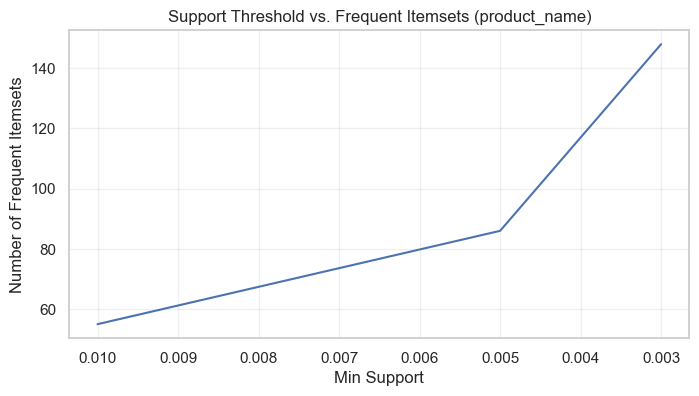

### Hyperparameter Sweep: **AISLE**

- Support `0.05`: Found `49` itemsets in `0.22s`

- Support `0.02`: Found `109` itemsets in `0.23s`

- Support `0.01`: Found `220` itemsets in `0.32s`

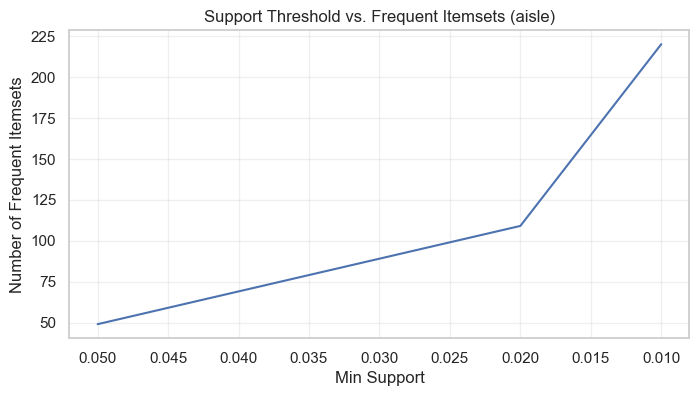

### Hyperparameter Sweep: **DEPARTMENT**

- Support `0.2`: Found `14` itemsets in `0.17s`

- Support `0.1`: Found `37` itemsets in `0.25s`

- Support `0.075`: Found `49` itemsets in `0.30s`

- Support `0.05`: Found `73` itemsets in `0.25s`

- Support `0.025`: Found `131` itemsets in `0.31s`

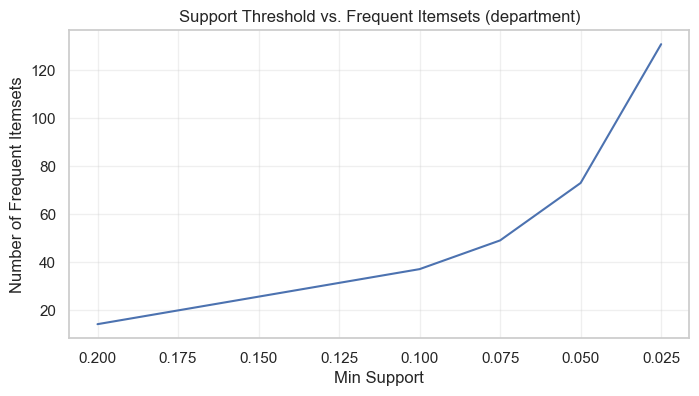

: 

In [ ]:
df_merged = load_and_prep_data()
df_subset = df_merged.sample(n=100000, random_state=42)
find_support_elbow(df_subset, level='product_name', thresholds=[0.01, 0.005, 0.003]) 
find_support_elbow(df_subset, level='aisle', thresholds=[0.05, 0.02, 0.01])
find_support_elbow(df_subset, level='department', thresholds=[0.2, 0.1, 0.075, 0.05, 0.025])

## Exploratory Data Analysis

--- Missing Values Check ---

,Missing Count
product_name,0
aisle,0
department,0
order_hour_of_day,0
order_dow,0


- **Total transactions (orders):** `200,000`
- **Total unique products:** `40,620`

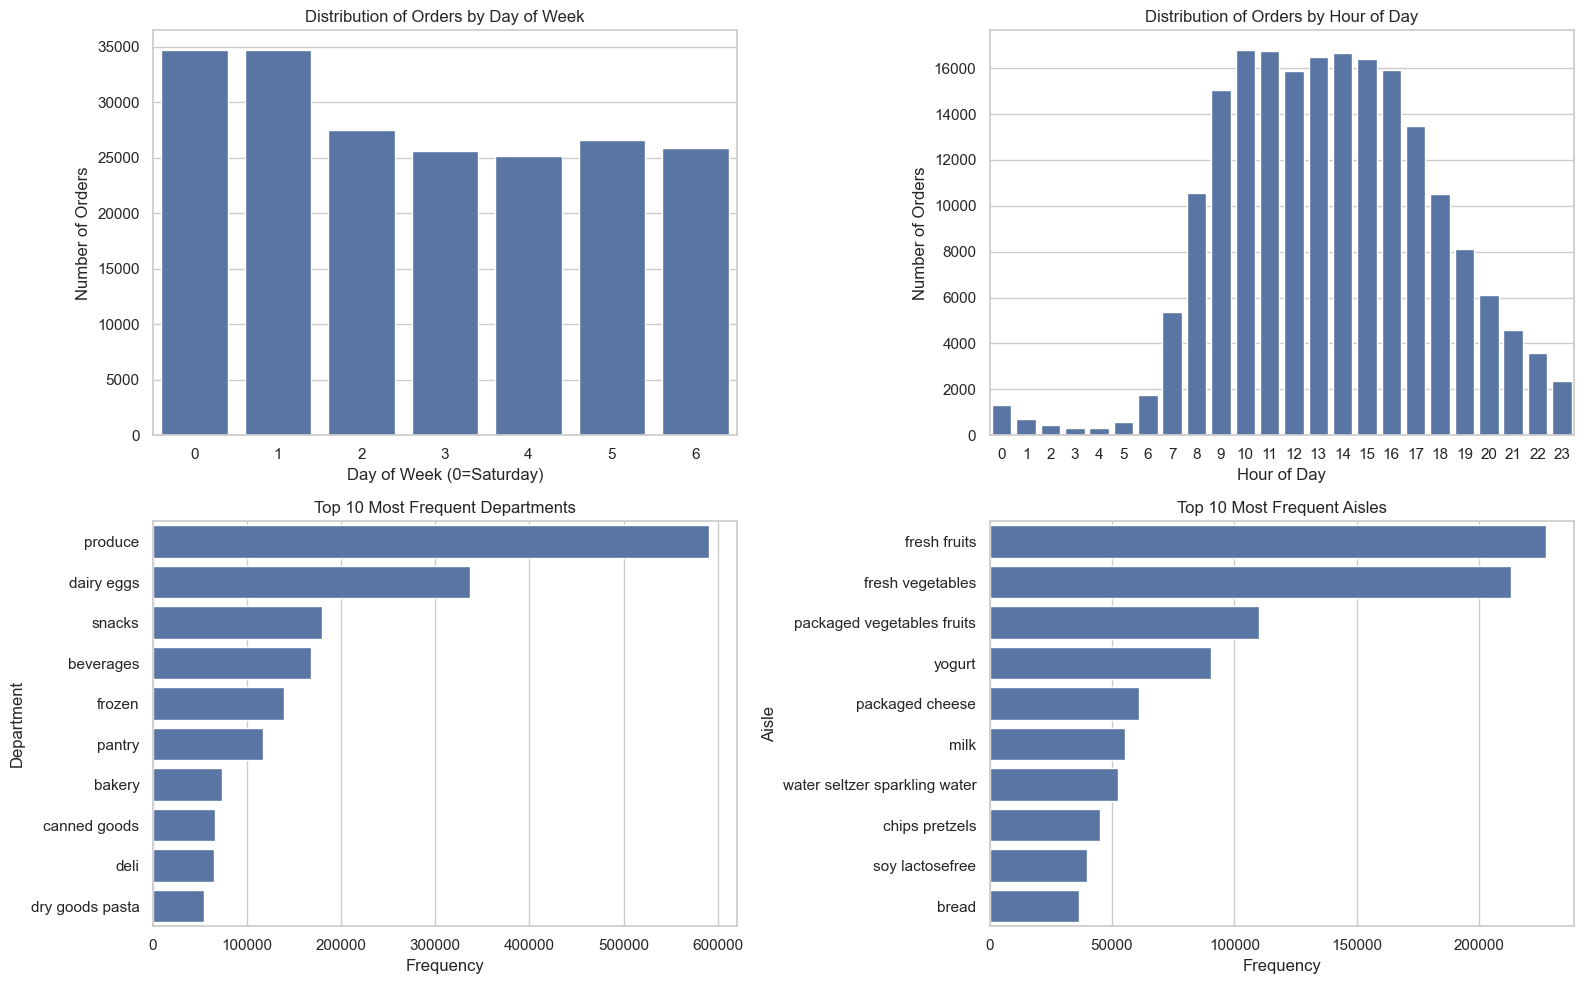

### Top 10 Products by Reorder Loyalty

product_name
+Energy Black Cherry Vegetable & Fruit Juice    1.0
Large Rings Dry Pasta                           1.0
Lasagna Bake                                    1.0
0% Fat Greek Yogurt Vanilla                     1.0
Ziti Rigati                                     1.0
with Mac & Cheese Fish Sticks                   1.0
Coldstone Sweet Cream                           1.0
Rainbow Rotini Pasta                            1.0
Rainbow Salad                                   1.0
Rainbow Sherbet Ice Cream                       1.0
Name: reordered, dtype: float64

<br>

---
## DIMENSION: **WEEKEND**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `18,684`
- **Unique Rules:** `18,684`
- **Robust Rules:** `240`

**Performance:** Apriori took `4.54s` | FP-Growth took `0.63s` *(FP-Growth is **7.2x** faster)*

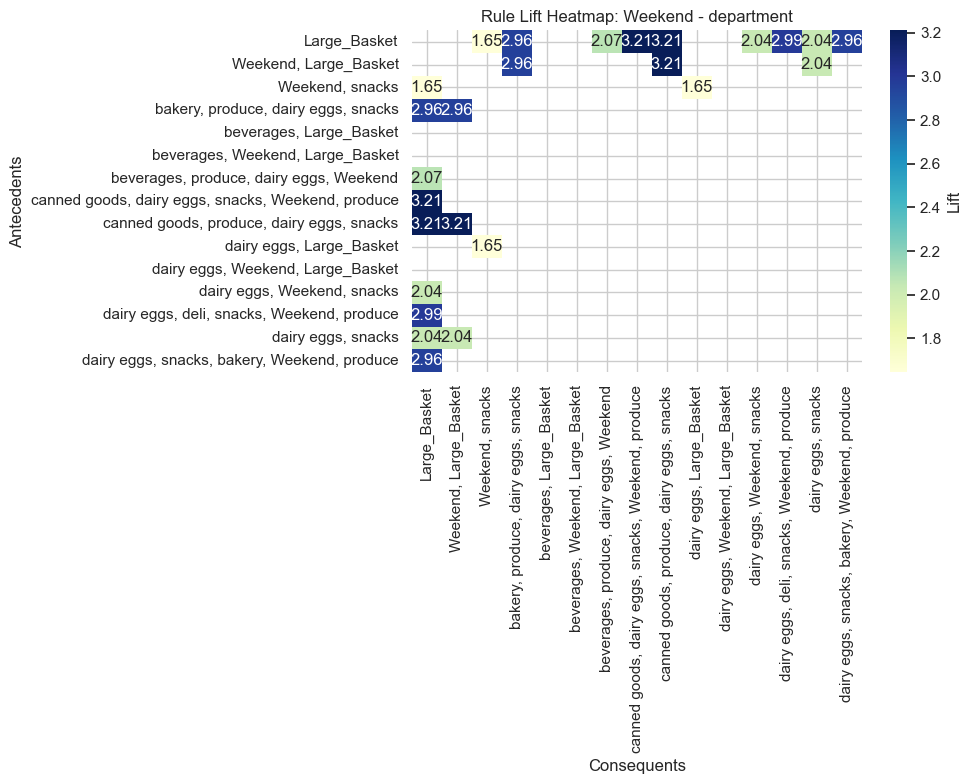

---

Skipping Apriori for aisle: negative dimensions are not allowed


### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `292,908`
- **Unique Rules:** `223,260`
- **Robust Rules:** `66`

**Performance:** FP-Growth took `7.63s`

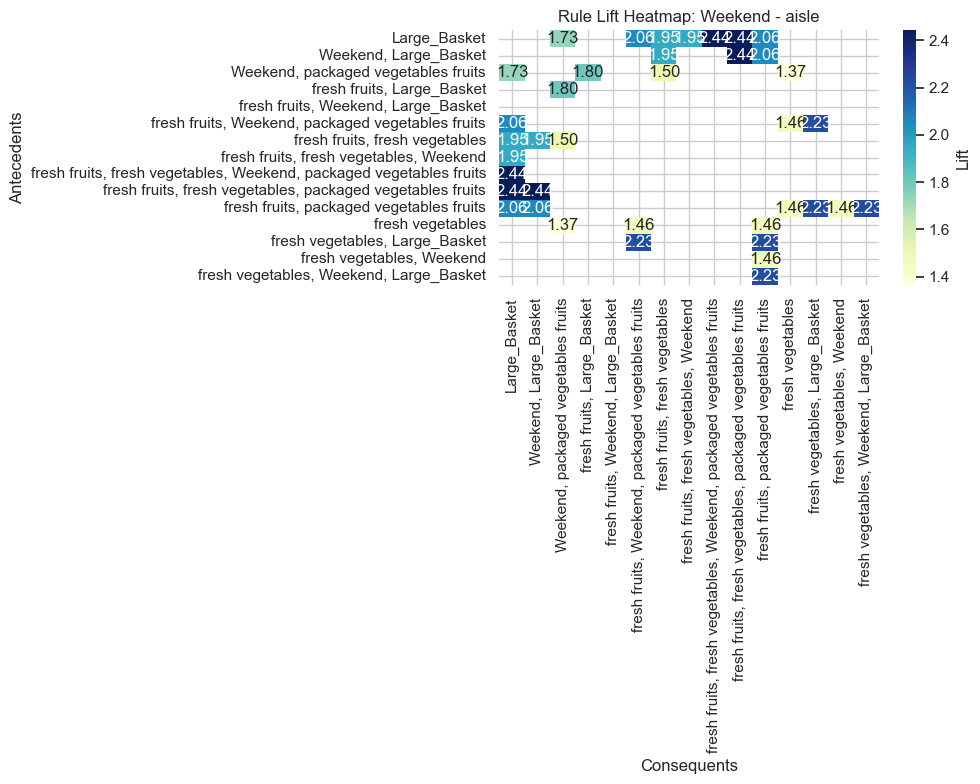

---

Skipping Apriori for product_name: Unable to allocate 46.9 GiB for an array with shape (69360, 726615) and data type bool


### LEVEL: **PRODUCT_NAME** *(Min Support: 0.0015)*

- **Rules Found:** `43,896`
- **Unique Rules:** `20,394`
- **Robust Rules:** `60`

**Performance:** FP-Growth took `6.92s`

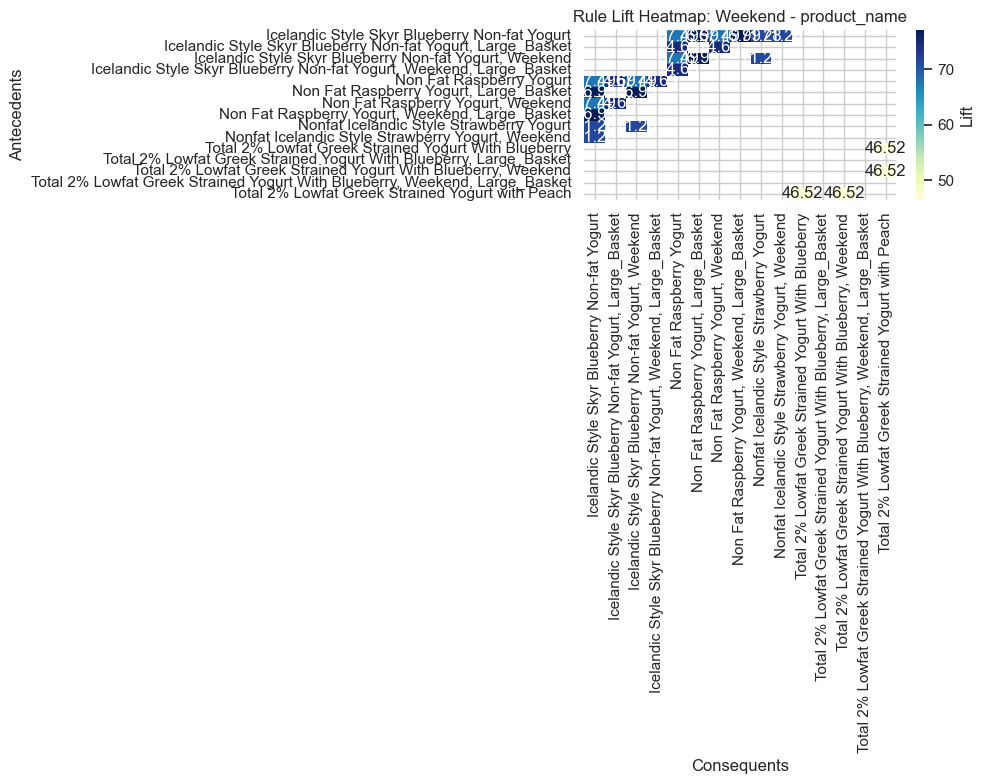

---

<br>

---
## DIMENSION: **WEEKDAY**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `12,090`
- **Unique Rules:** `12,090`
- **Robust Rules:** `102`

**Performance:** Apriori took `6.43s` | FP-Growth took `0.95s` *(FP-Growth is **6.8x** faster)*

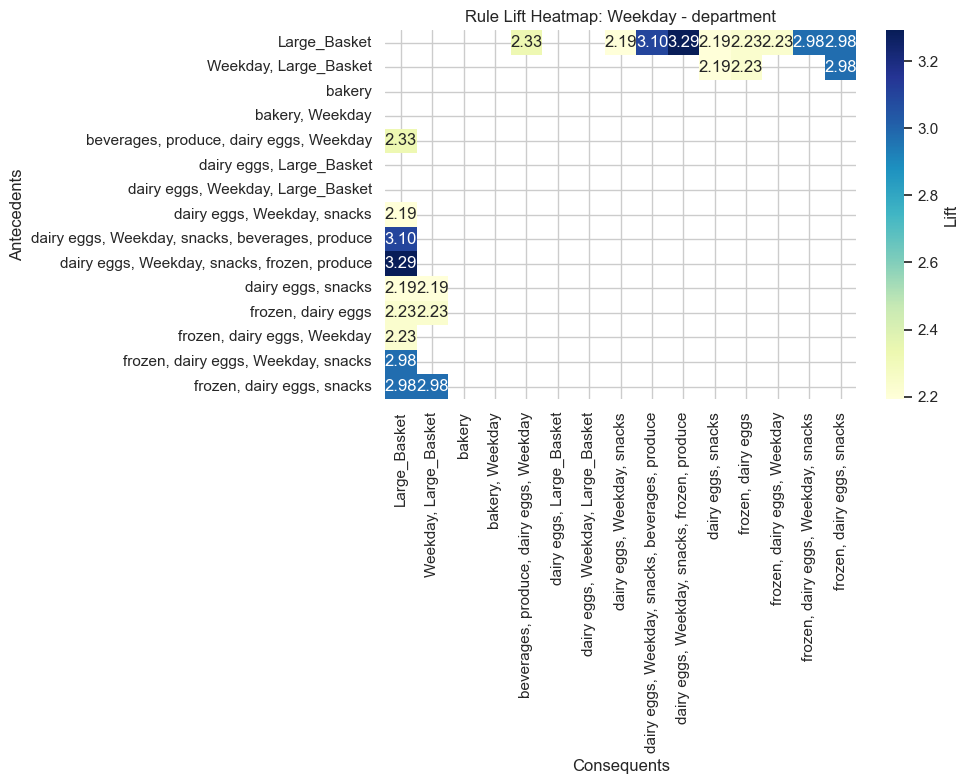

---

Skipping Apriori for aisle: Unable to allocate 5.52 GiB for an array with shape (130639, 45400) and data type bool


### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `160,938`
- **Unique Rules:** `116,928`
- **Robust Rules:** `48`

**Performance:** FP-Growth took `11.28s`

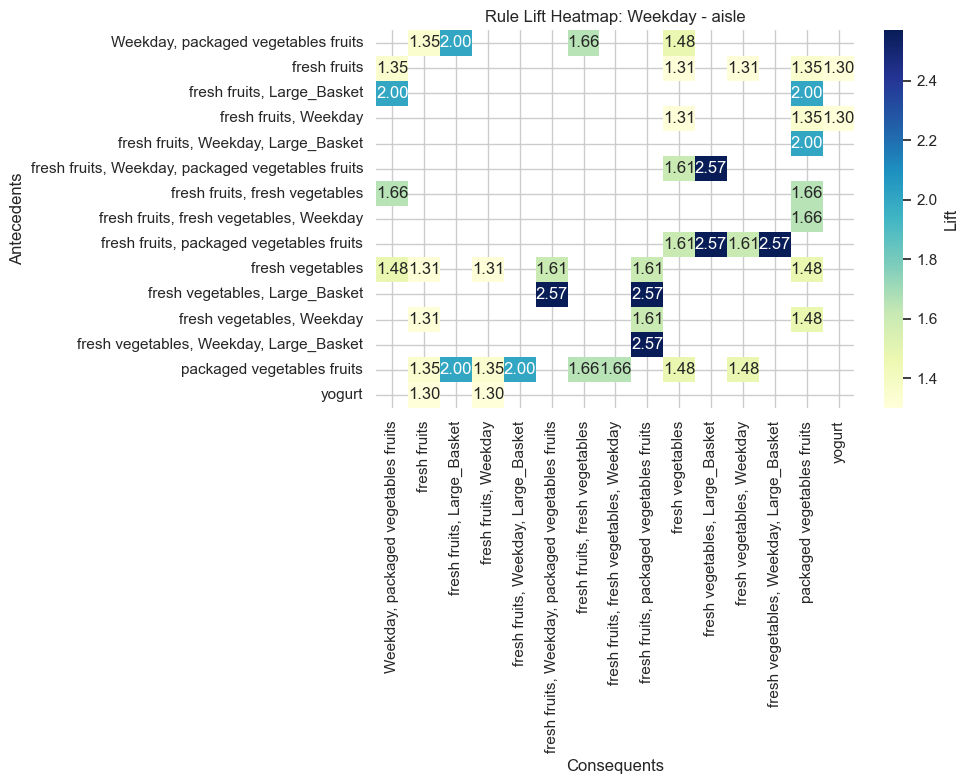

---

Skipping Apriori for product_name: Unable to allocate 78.0 GiB for an array with shape (130639, 641278) and data type bool


### LEVEL: **PRODUCT_NAME** *(Min Support: 0.0015)*

- **Rules Found:** `25,086`
- **Unique Rules:** `8,946`
- **Robust Rules:** `42`

**Performance:** FP-Growth took `12.08s`

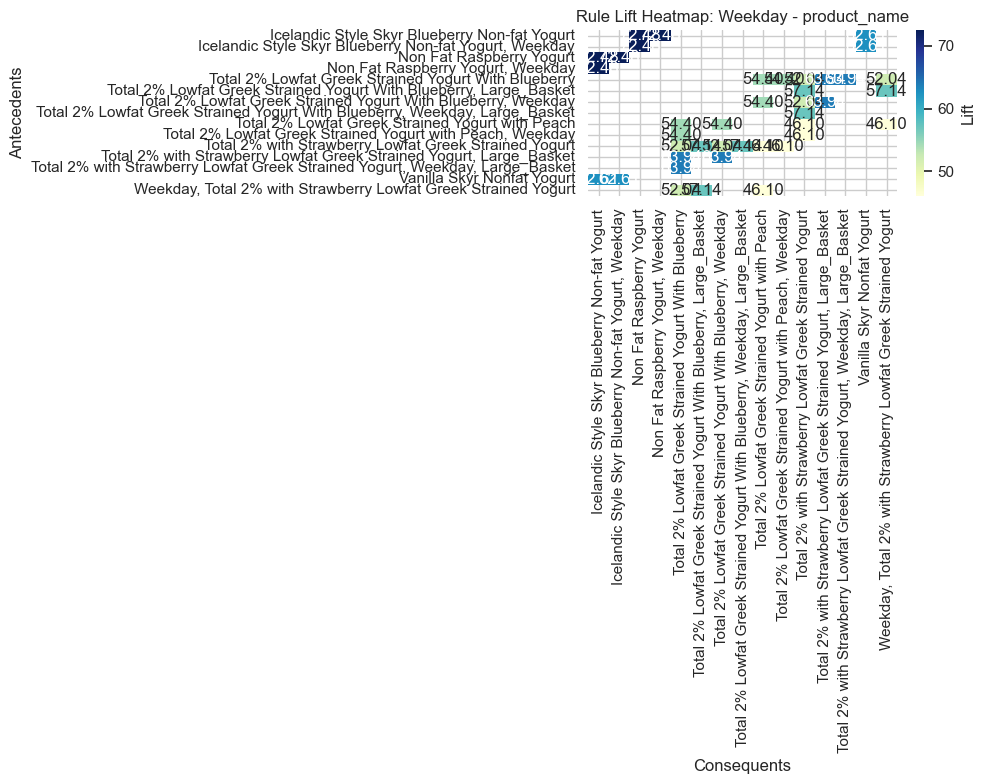

---

<br>

---
## DIMENSION: **HOUR_MORNING**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `18,666`
- **Unique Rules:** `18,666`
- **Robust Rules:** `204`

**Performance:** Apriori took `4.03s` | FP-Growth took `0.53s` *(FP-Growth is **7.6x** faster)*

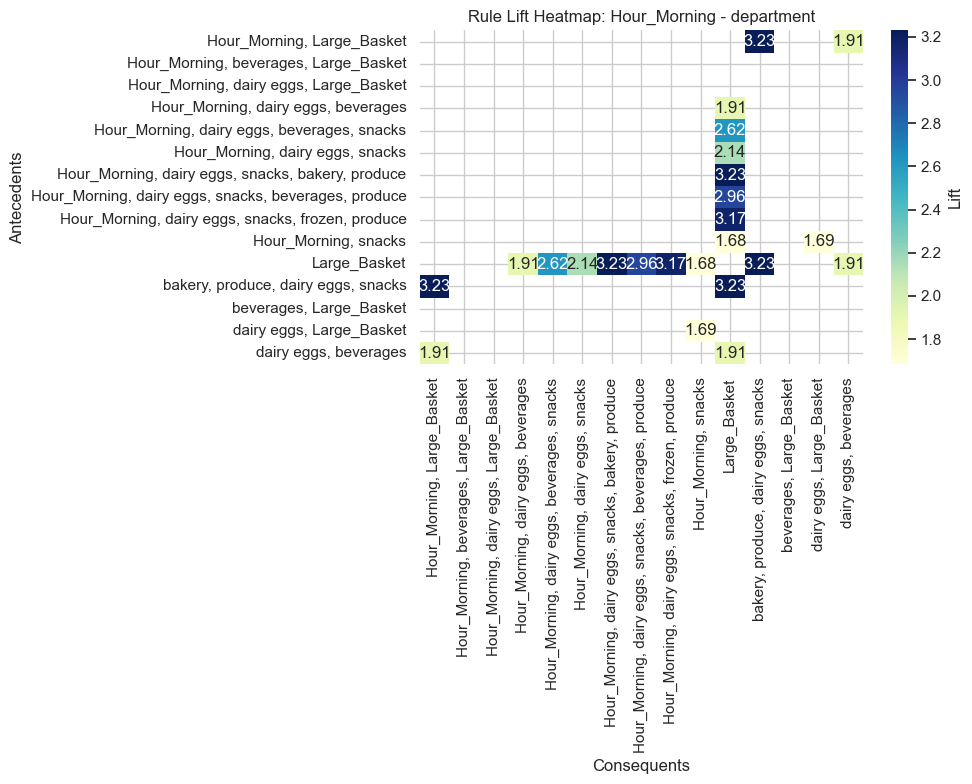

---

Skipping Apriori for aisle: negative dimensions are not allowed


### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `288,492`
- **Unique Rules:** `216,276`
- **Robust Rules:** `78`

**Performance:** FP-Growth took `6.56s`

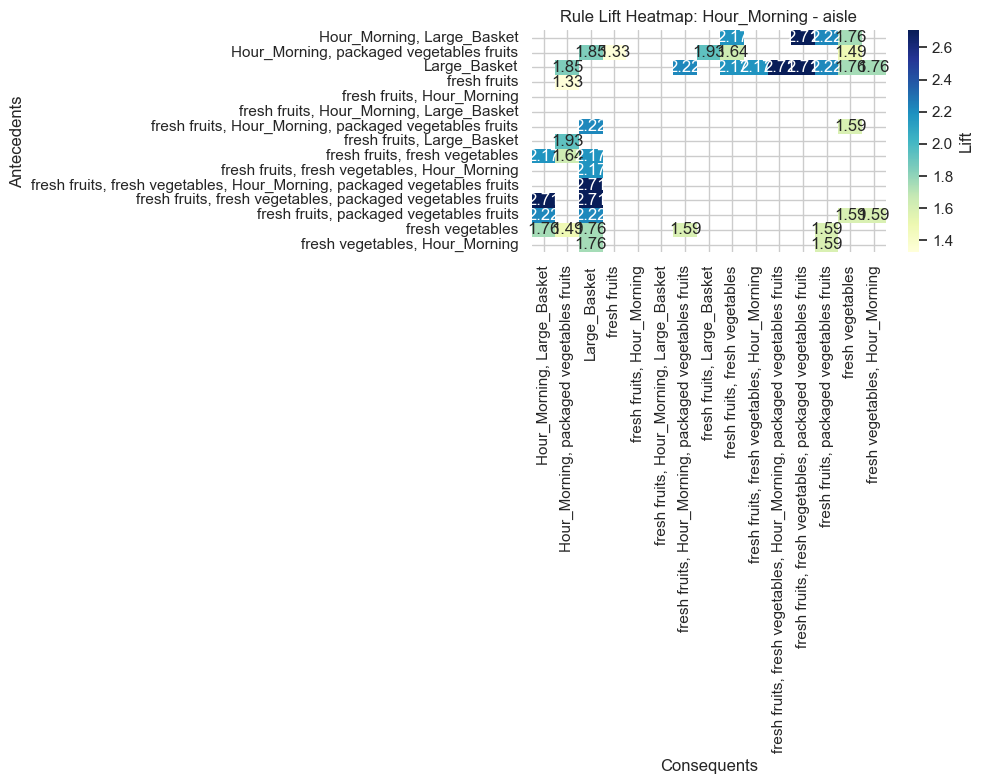

---

Skipping Apriori for product_name: Unable to allocate 42.8 GiB for an array with shape (66284, 693253) and data type bool


### LEVEL: **PRODUCT_NAME** *(Min Support: 0.0015)*

- **Rules Found:** `41,370`
- **Unique Rules:** `17,250`
- **Robust Rules:** `162`

**Performance:** FP-Growth took `6.76s`

C:\Users\BerenÜnveren\AppData\Local\Temp\ipykernel_9268\3509959516.py:229: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


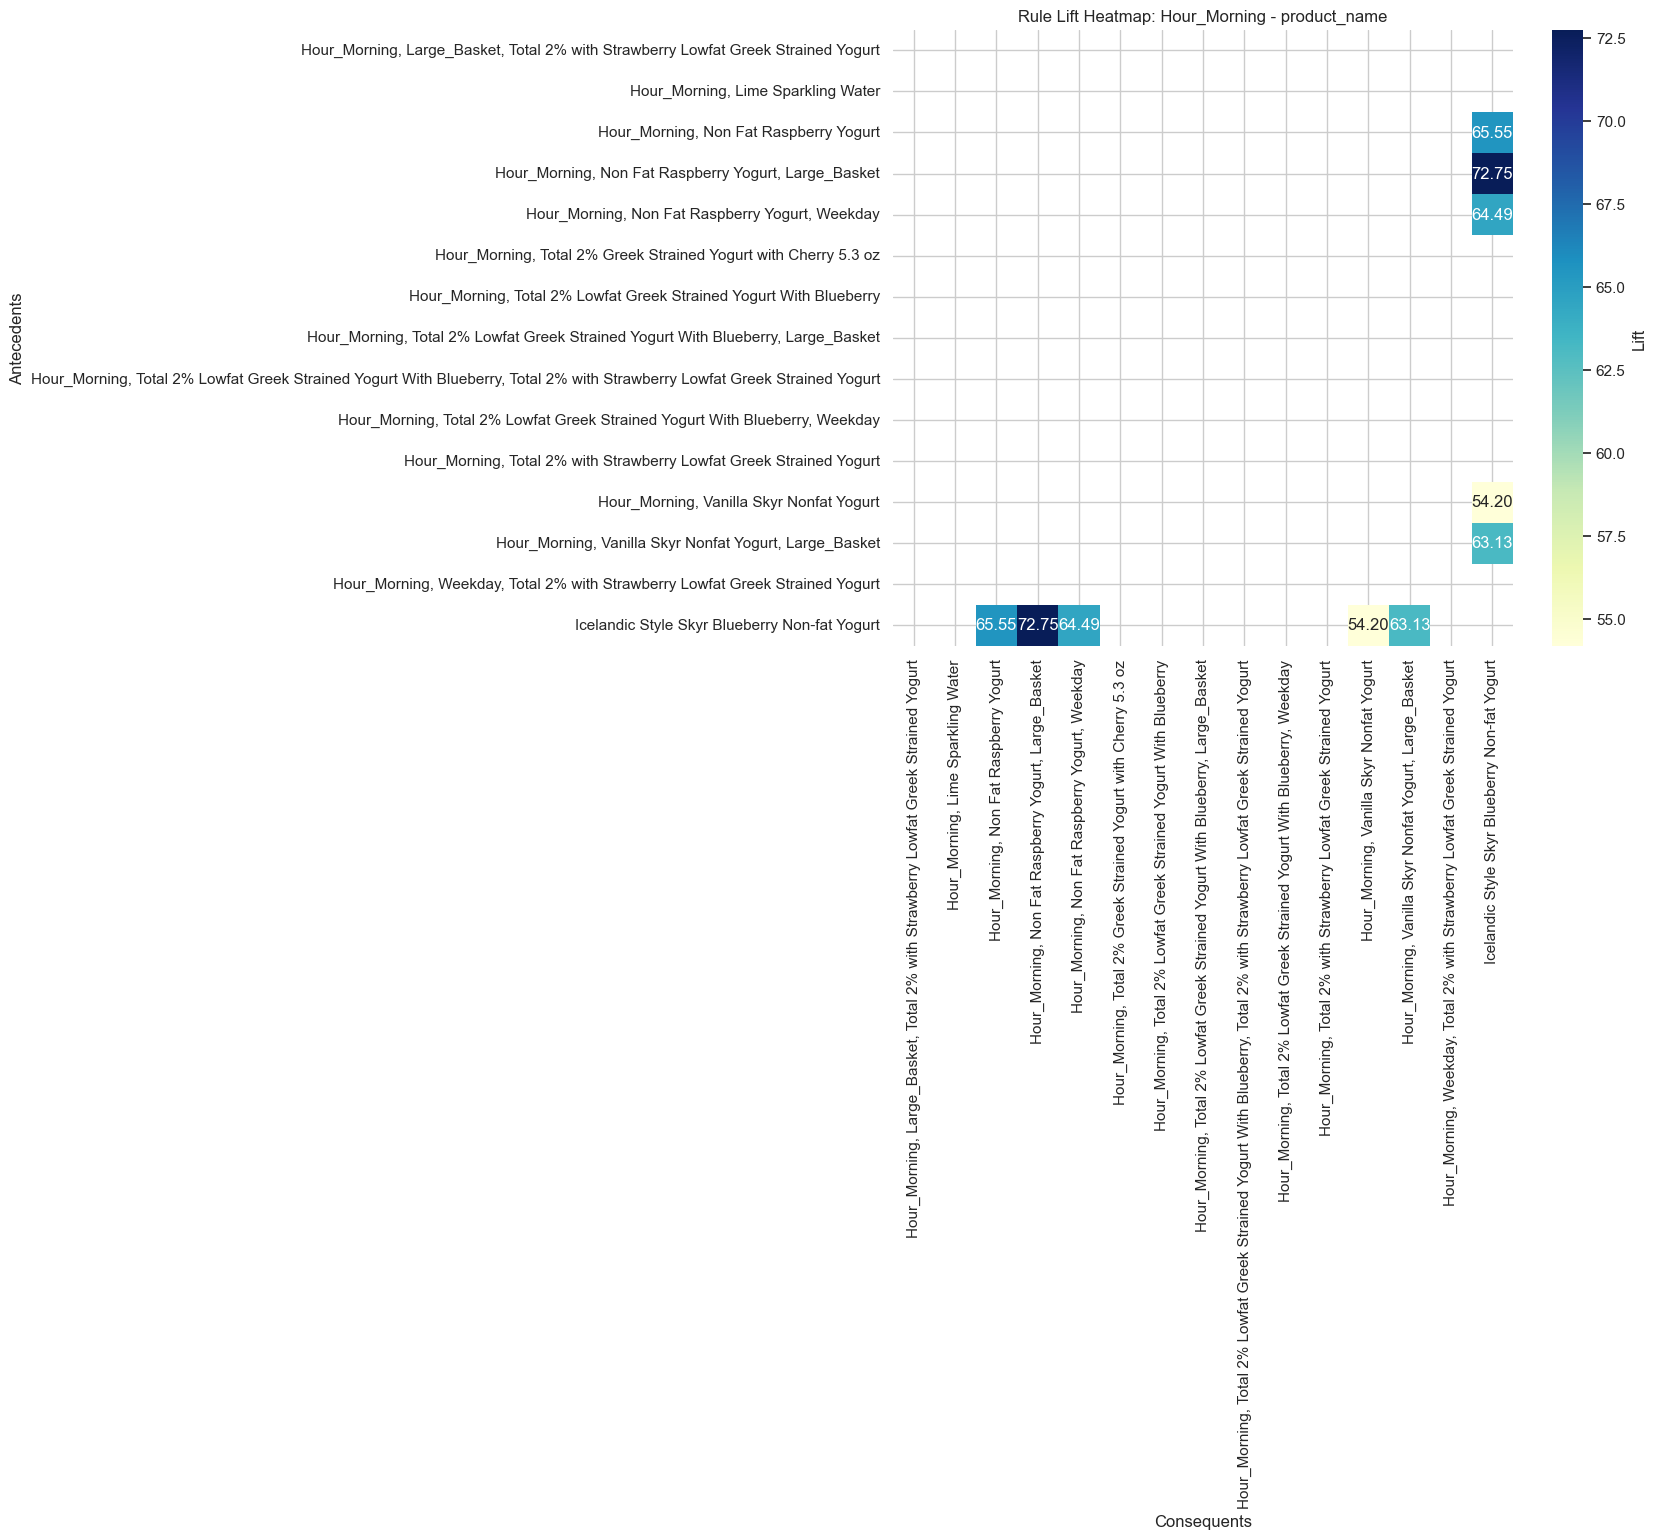

---

<br>

---
## DIMENSION: **HOUR_AFTERNOON**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `17,274`
- **Unique Rules:** `17,274`
- **Robust Rules:** `126`

**Performance:** Apriori took `6.13s` | FP-Growth took `0.60s` *(FP-Growth is **10.2x** faster)*

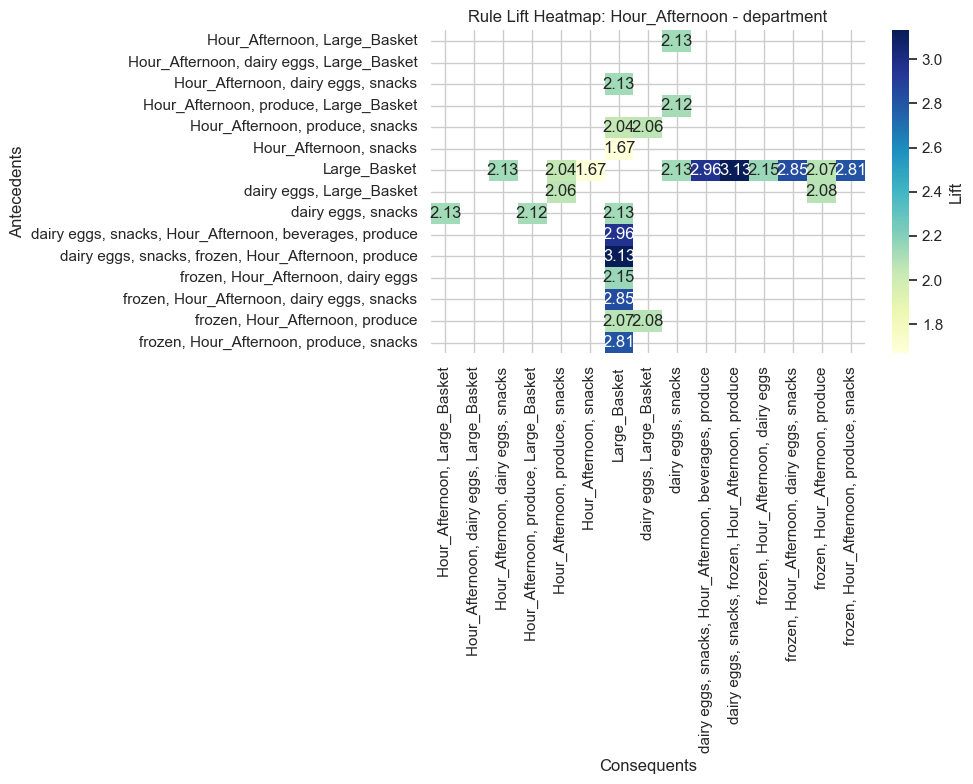

---

In [ ]:
results = run_master_analysis(df_merged)

In [ ]:
display(Markdown("### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))"))

conflicts_found = False
for (dim, level), df in results.items():
    if not df.empty:
        conflicting_rules = df[(df['lift'] > 2) & (df['kulczynski'] < 0.4)].copy()        
        if not conflicting_rules.empty:
            conflicts_found = True
            display(Markdown(f"**Dimension:** `{dim}` | **Level:** `{level}`"))
            conflicting_rules = conflicting_rules.sort_values('ir', ascending=False)
            cols_to_show = ['ant_str', 'cons_str', 'support', 'confidence', 'lift', 'kulczynski', 'ir']
            display(conflicting_rules[cols_to_show].head(5))

### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))

**Dimension:** `Weekend` | **Level:** `department`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
18665,"pantry, produce","meat seafood, Weekend, Large_Basket",0.050245,0.166118,2.036405,0.39103,0.661757
18644,"meat seafood, Large_Basket","pantry, produce",0.050245,0.615942,2.036405,0.39103,0.661757
18663,"meat seafood, Large_Basket","pantry, produce, Weekend",0.050245,0.615942,2.036405,0.39103,0.661757
18654,"meat seafood, Weekend, Large_Basket","pantry, produce",0.050245,0.615942,2.036405,0.39103,0.661757
18656,"pantry, produce, Weekend","meat seafood, Large_Basket",0.050245,0.166118,2.036405,0.39103,0.661757


**Dimension:** `Weekend` | **Level:** `aisle`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
291907,"fresh fruits, fresh vegetables","latino foods, Weekend, Large_Basket",0.010006,0.027695,2.131965,0.398975,0.956147
291904,"latino foods, Weekend, Large_Basket","fresh fruits, fresh vegetables",0.010006,0.770255,2.131965,0.398975,0.956147
291899,"fresh fruits, fresh vegetables, Weekend","latino foods, Large_Basket",0.010006,0.027695,2.131965,0.398975,0.956147
291912,"latino foods, Large_Basket","fresh fruits, fresh vegetables, Weekend",0.010006,0.770255,2.131965,0.398975,0.956147
291887,"latino foods, Large_Basket","fresh fruits, fresh vegetables",0.010006,0.770255,2.131965,0.398975,0.956147


...

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
13943,"pantry, produce, Large_Basket, snacks","dairy eggs, beverages",0.050483,0.628866,2.010264,0.395121,0.678744
14033,"pantry, produce, Large_Basket, snacks","Hour_Night, dairy eggs, beverages",0.050483,0.628866,2.010264,0.395121,0.678744
14003,"pantry, Hour_Night, snacks, produce, Large_Basket","dairy eggs, beverages",0.050483,0.628866,2.010264,0.395121,0.678744
13976,"dairy eggs, beverages","pantry, produce, Large_Basket, snacks",0.050483,0.161376,2.010264,0.395121,0.678744
14066,"Hour_Night, dairy eggs, beverages","pantry, produce, Large_Basket, snacks",0.050483,0.161376,2.010264,0.395121,0.678744


**Dimension:** `Hour_Night` | **Level:** `aisle`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
149634,packaged vegetables fruits,"butter, yogurt, Hour_Night, fresh vegetables, ...",0.010207,0.026792,2.023368,0.398813,0.957615
53824,"chips pretzels, fresh vegetables, Hour_Night, ...",packaged vegetables fruits,0.010207,0.770833,2.023368,0.398813,0.957615
149581,"butter, yogurt, Hour_Night, fresh vegetables, ...",packaged vegetables fruits,0.010207,0.770833,2.023368,0.398813,0.957615
148249,"fresh fruits, milk, butter, Large_Basket",packaged vegetables fruits,0.010207,0.770833,2.023368,0.398813,0.957615
53843,packaged vegetables fruits,"chips pretzels, fresh vegetables, Hour_Night, ...",0.010207,0.026792,2.023368,0.398813,0.957615


**Dimension:** `Hour_Night` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
53414,"Hour_Night, Weekend",Red Mango,0.001655,0.004946,2.241344,0.377473,0.99177
53415,"Hour_Night, Red Mango",Weekend,0.001655,0.750000,2.241344,0.377473,0.99177
53409,Red Mango,Weekend,0.001655,0.750000,2.241344,0.377473,0.99177
53408,Weekend,Red Mango,0.001655,0.004946,2.241344,0.377473,0.99177
53416,Weekend,"Hour_Night, Red Mango",0.001655,0.004946,2.241344,0.377473,0.99177


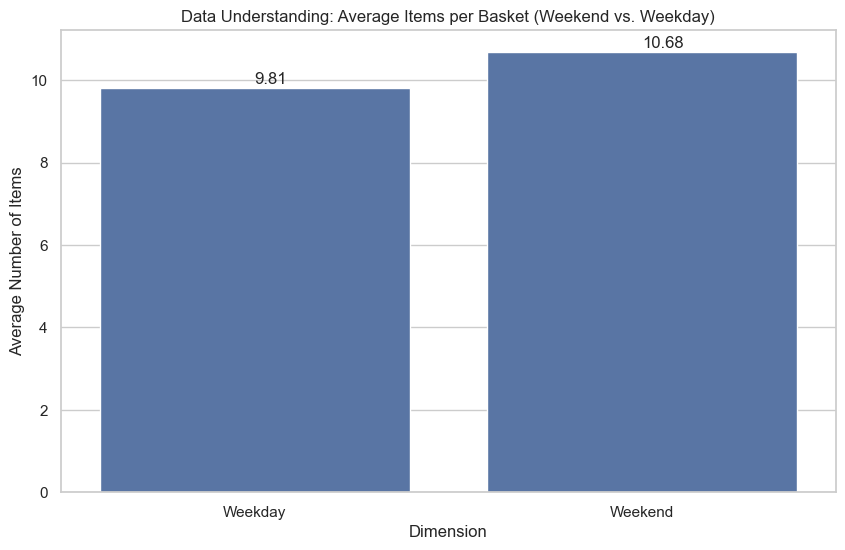

Weekend baskets are larger than Weekday baskets on average


##Multi-Level & Multi-Dimensional Mining Summary

,Dimension,Level,Total_Found,Robust_Count,Avg_Lift,Avg_Kulc
0,Weekend,Department,18684,240,1.8831,0.3948
1,Weekend,Aisle,223260,66,2.1328,0.2704
2,Weekend,Product_name,20394,60,2.7720,0.1104
3,Weekday,Department,12090,102,1.8993,0.4008
4,Weekday,Aisle,116928,48,2.2429,0.2683
5,Weekday,Product_name,8946,42,3.3030,0.1146


The 'Total_Found' column shows rules after hierarchical redundancy filtering

The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds

### Top 5 Robust Product Rules (Weekend vs. Weekday)

,Dimension,ant_str,cons_str,lift,kulczynski,cosine
0,Weekend,"Non Fat Raspberry Yogurt, Weekend, Large_Basket",Icelandic Style Skyr Blueberry Non-fat Yogurt,76.987,0.371,0.341
1,Weekend,"Icelandic Style Skyr Blueberry Non-fat Yogurt,...","Non Fat Raspberry Yogurt, Large_Basket",76.987,0.371,0.341
2,Weekend,Icelandic Style Skyr Blueberry Non-fat Yogurt,"Non Fat Raspberry Yogurt, Large_Basket",76.987,0.371,0.341
3,Weekend,"Non Fat Raspberry Yogurt, Large_Basket",Icelandic Style Skyr Blueberry Non-fat Yogurt,76.987,0.371,0.341
4,Weekend,"Non Fat Raspberry Yogurt, Large_Basket","Icelandic Style Skyr Blueberry Non-fat Yogurt,...",76.987,0.371,0.341
5,Weekday,Non Fat Raspberry Yogurt,Icelandic Style Skyr Blueberry Non-fat Yogurt,72.484,0.400,0.398
6,Weekday,Icelandic Style Skyr Blueberry Non-fat Yogurt,Non Fat Raspberry Yogurt,72.484,0.400,0.398
7,Weekday,Non Fat Raspberry Yogurt,"Icelandic Style Skyr Blueberry Non-fat Yogurt,...",72.484,0.400,0.398
8,Weekday,Icelandic Style Skyr Blueberry Non-fat Yogurt,"Non Fat Raspberry Yogurt, Weekday",72.484,0.400,0.398
9,Weekday,"Non Fat Raspberry Yogurt, Weekday",Icelandic Style Skyr Blueberry Non-fat Yogurt,72.484,0.400,0.398


### Robust Patterns: Morning vs. Night Shoppers

,Dimension,ant_str,cons_str,lift,kulczynski,cosine
0,Hour_Morning,"Hour_Morning, Non Fat Raspberry Yogurt, Large_...",Icelandic Style Skyr Blueberry Non-fat Yogurt,72.746,0.384,0.351
1,Hour_Morning,"Non Fat Raspberry Yogurt, Large_Basket",Icelandic Style Skyr Blueberry Non-fat Yogurt,72.746,0.384,0.351
2,Hour_Morning,"Non Fat Raspberry Yogurt, Large_Basket","Icelandic Style Skyr Blueberry Non-fat Yogurt,...",72.746,0.384,0.351
3,Hour_Morning,Icelandic Style Skyr Blueberry Non-fat Yogurt,"Non Fat Raspberry Yogurt, Large_Basket",72.746,0.384,0.351
4,Hour_Morning,Icelandic Style Skyr Blueberry Non-fat Yogurt,"Hour_Morning, Non Fat Raspberry Yogurt, Large_...",72.746,0.384,0.351
5,Hour_Night,"Nonfat Icelandic Style Strawberry Yogurt, Weekday","Icelandic Style Skyr Blueberry Non-fat Yogurt,...",110.969,0.429,0.429
6,Hour_Night,"Icelandic Style Skyr Blueberry Non-fat Yogurt,...","Nonfat Icelandic Style Strawberry Yogurt, Weekday",110.969,0.429,0.429
7,Hour_Night,"Icelandic Style Skyr Blueberry Non-fat Yogurt,...","Nonfat Icelandic Style Strawberry Yogurt, Hour...",110.969,0.429,0.429
8,Hour_Night,"Nonfat Icelandic Style Strawberry Yogurt, Hour...","Icelandic Style Skyr Blueberry Non-fat Yogurt,...",110.969,0.429,0.429
9,Hour_Night,"Nonfat Icelandic Style Strawberry Yogurt, Weekday","Icelandic Style Skyr Blueberry Non-fat Yogurt,...",110.969,0.429,0.429


In [ ]:
plt.figure(figsize=(10, 6))
basket_stats = df_merged.groupby(['day_type', 'order_id']).size().reset_index(name='items')
avg_items = basket_stats.groupby('day_type')['items'].mean()

sns.barplot(x=avg_items.index, y=avg_items.values)
plt.title('Data Understanding: Average Items per Basket (Weekend vs. Weekday)')
plt.ylabel('Average Number of Items')
plt.xlabel('Dimension')
for i, v in enumerate(avg_items.values): plt.text(i, v + 0.1, f"{v:.2f}")
plt.show()
print(f"{avg_items.idxmax()} baskets are larger than {avg_items.idxmin()} baskets on average")

summary_data = []

for dim in ['Weekend', 'Weekday']:
    for level in ['department', 'aisle', 'product_name']:
        key = (dim, level)
        if key in results:
            df = results[key]
            summary_data.append({
                'Dimension': dim,
                'Level': level.capitalize(),
                'Total_Found': len(df),
                'Robust_Count': df['is_robust'].sum(),
                'Avg_Lift': round(df['lift'].mean(), 4) if not df.empty else 0,
                'Avg_Kulc': round(df['kulczynski'].mean(), 4) if not df.empty else 0
            })

summary_df = pd.DataFrame(summary_data)
display(Markdown("##Multi-Level & Multi-Dimensional Mining Summary"))
display(summary_df)
display(Markdown("The 'Total_Found' column shows rules after hierarchical redundancy filtering"))
display(Markdown("The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds"))

weekend_top = get_top_robust('Weekend', 'product_name', results)
weekday_top = get_top_robust('Weekday', 'product_name', results)
comparison_table = pd.concat([weekend_top, weekday_top], ignore_index=True)

display(Markdown("### Top 5 Robust Product Rules (Weekend vs. Weekday)"))
display(comparison_table)

morning_top = get_top_robust('Hour_Morning', 'product_name', results)
night_top = get_top_robust('Hour_Night', 'product_name', results)

hourly_comparison = pd.concat([morning_top, night_top], ignore_index=True)

display(Markdown("### Robust Patterns: Morning vs. Night Shoppers"))
display(hourly_comparison)